<center> <h1> Netflix Content Segmentation </h1> </center>

In [60]:
#Import required libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Ignore all incoming-warnings (if any):
import warnings
warnings.filterwarnings("ignore")




# load data
df = pd.read_csv("dataset.csv")

# ---------------------------
# 1. Handle missing values
# ---------------------------
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')

# drop rows where date_added missing (small count)
df = df.dropna(subset=['date_added'])

# ---------------------------
# 2. Convert date column
# ---------------------------
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# extract useful features
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# ---------------------------
# 3. Clean text columns
# ---------------------------
df['title'] = df['title'].str.strip()
df['description'] = df['description'].str.lower()

# ---------------------------
# 4. Remove duplicates
# ---------------------------
df = df.drop_duplicates(subset='title')

# ---------------------------
# 5. Standardize country (take first country)
# ---------------------------
df['main_country'] = df['country'].apply(lambda x: x.split(',')[0])

# ---------------------------
# 6. Genre cleaning
# ---------------------------
df['main_genre'] = df['genres'].apply(lambda x: x.split(',')[0])

# ---------------------------
# 7. Cast count feature
# ---------------------------
df['cast_count'] = df['cast'].apply(lambda x: 0 if x == 'Unknown' else len(x.split(',')))

# ---------------------------
# 8. Description features
# ---------------------------
df['description_length'] = df['description'].apply(len)
df['description_word_count'] = df['description'].apply(lambda x: len(x.split()))

# ---------------------------
# 9. Content age
# ---------------------------
current_year = 2026
df['content_age'] = current_year - df['release_year']

print(df.head())

  show_id     type                                      title        director  \
0      s1  TV Show                                         3%         Unknown   
1     s10    Movie                                       1920    Vikram Bhatt   
2    s100    Movie                                 3 Heroines  Iman Brotoseno   
3   s1000    Movie  Blue Mountain State: The Rise of Thadland    Lev L. Spiro   
4   s1001  TV Show                             Blue Planet II         Unknown   

                                                cast         country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...          Brazil   
1  Rajneesh Duggal, Adah Sharma, Indraneil Sengup...           India   
2  Reza Rahadian, Bunga Citra Lestari, Tara Basro...       Indonesia   
3  Alan Ritchson, Darin Brooks, James Cade, Rob R...   United States   
4                                 David Attenborough  United Kingdom   

  date_added  release_year rating  duration  \
0 2020-08-14          2020  TV-MA

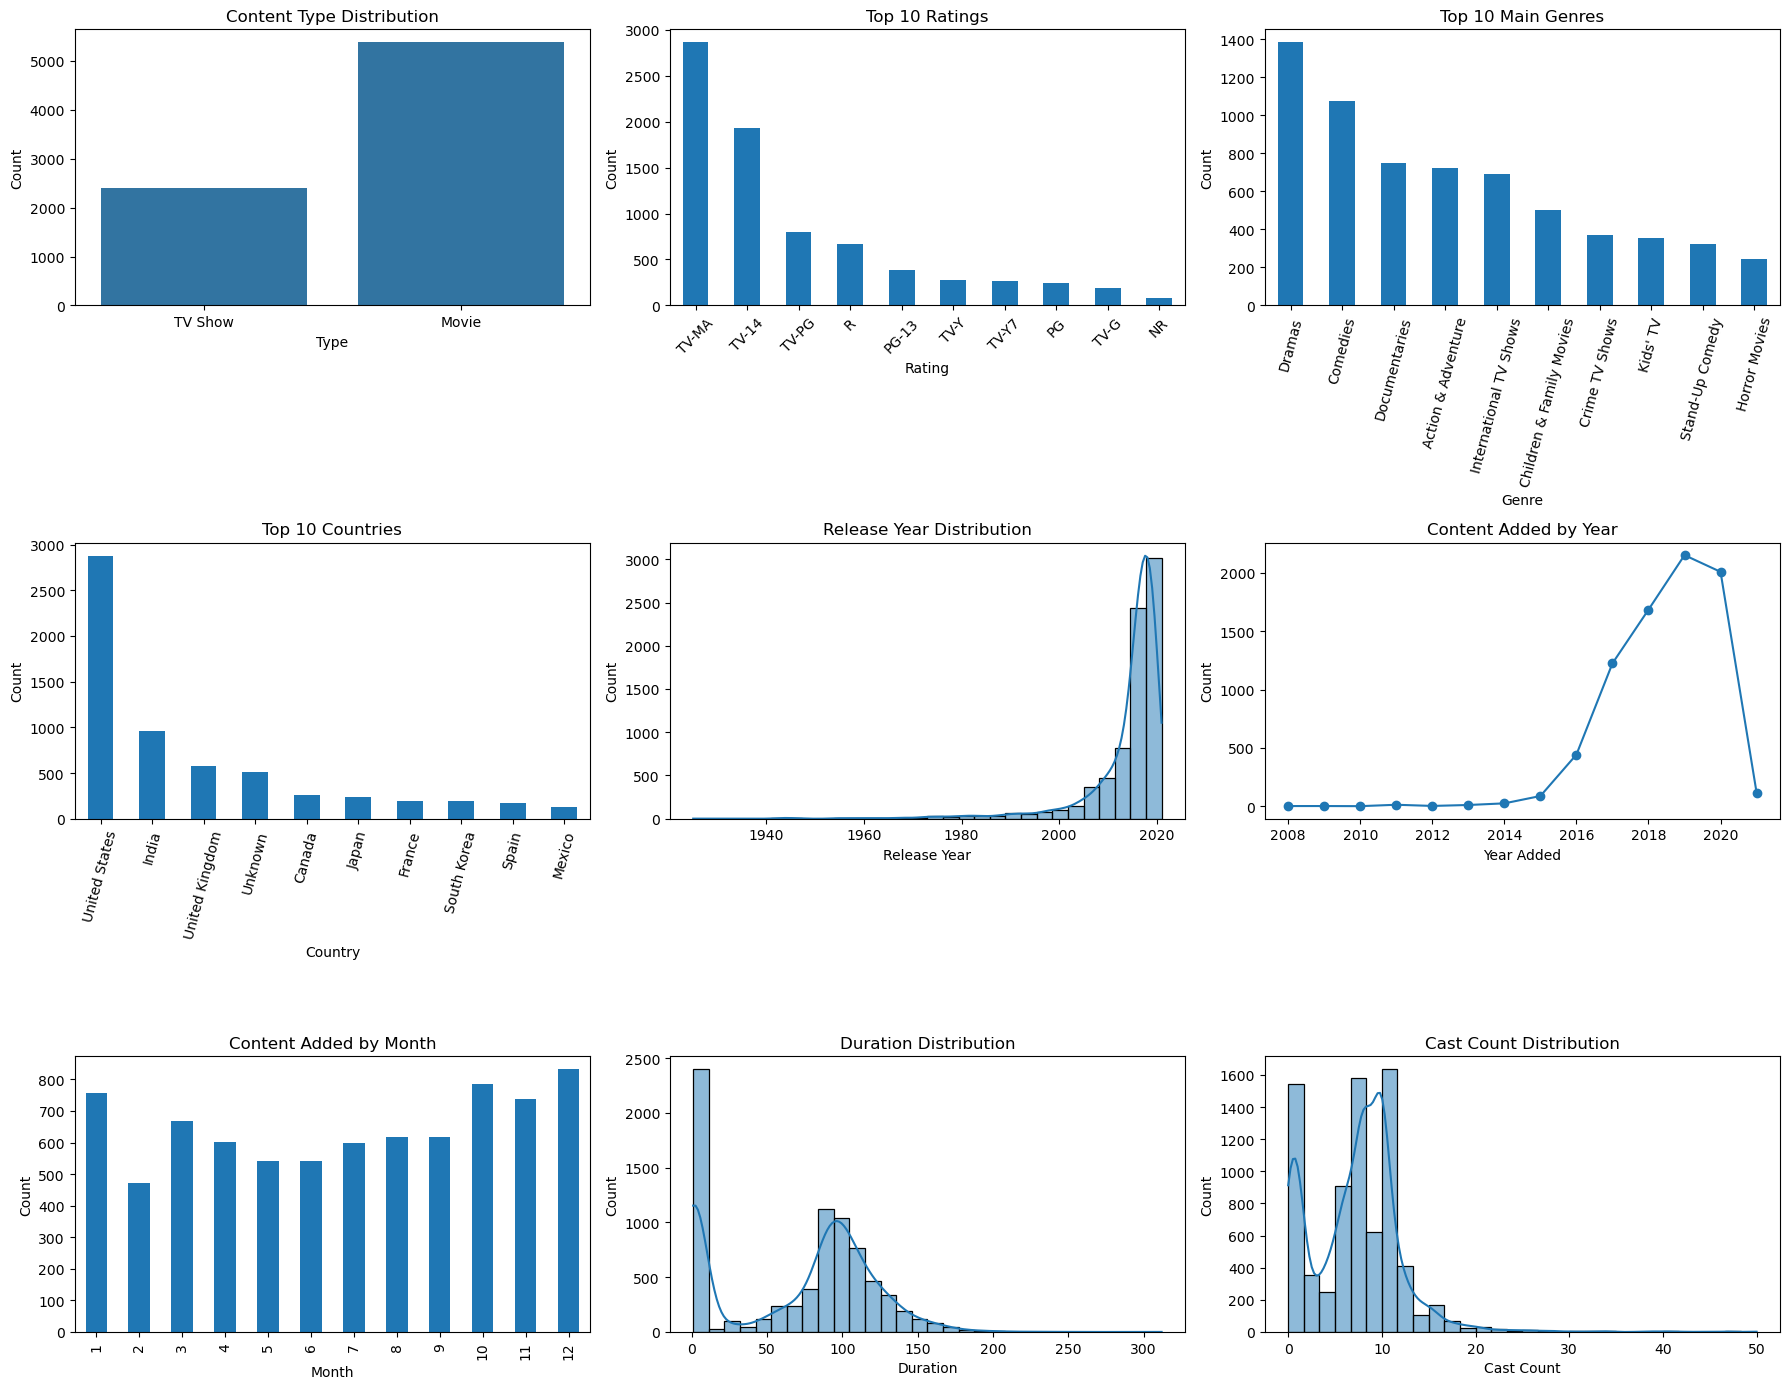

In [61]:
#Simple EDA:

plt.figure(figsize=(18, 14))

# 1. Movie vs TV Show count
plt.subplot(3, 3, 1)
sns.countplot(data=df, x='type')
plt.title("Content Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")

# 2. Top 10 ratings
plt.subplot(3, 3, 2)
df['rating'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)

# 3. Top 10 genres
plt.subplot(3, 3, 3)
df['main_genre'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Main Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=75)

# 4. Top 10 countries
plt.subplot(3, 3, 4)
df['main_country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=75)

# 5. Release year distribution
plt.subplot(3, 3, 5)
sns.histplot(df['release_year'], bins=30, kde=True)
plt.title("Release Year Distribution")
plt.xlabel("Release Year")
plt.ylabel("Count")

# 6. Content added by year
plt.subplot(3, 3, 6)
df['year_added'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title("Content Added by Year")
plt.xlabel("Year Added")
plt.ylabel("Count")

# 7. Content added by month
plt.subplot(3, 3, 7)
df['month_added'].value_counts().sort_index().plot(kind='bar')
plt.title("Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Count")

# 8. Duration distribution
plt.subplot(3, 3, 8)
sns.histplot(df['duration'], bins=30, kde=True)
plt.title("Duration Distribution")
plt.xlabel("Duration")
plt.ylabel("Count")

# 9. Cast count distribution
plt.subplot(3, 3, 9)
sns.histplot(df['cast_count'], bins=30, kde=True)
plt.title("Cast Count Distribution")
plt.xlabel("Cast Count")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [62]:
# Feature Engineering:
# select useful features
feature_df = df[[
    'type',
    'release_year',
    'duration',
    'main_genre',
    'main_country',
    'cast_count',
    'description_word_count',
    'content_age'
]]

# ---------------------------
# Encode categorical variables
# ---------------------------
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['type', 'main_genre', 'main_country']
num_cols = ['release_year', 'duration', 'cast_count', 'description_word_count', 'content_age']

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

X = preprocessor.fit_transform(feature_df)

print("Final Feature Shape:", X.shape)

Final Feature Shape: (7776, 125)


Clustering on 7327 titles with 125 features

Cluster Distribution:
Cluster
0    1158
1    3488
2    1430
3    1251
Name: count, dtype: int64


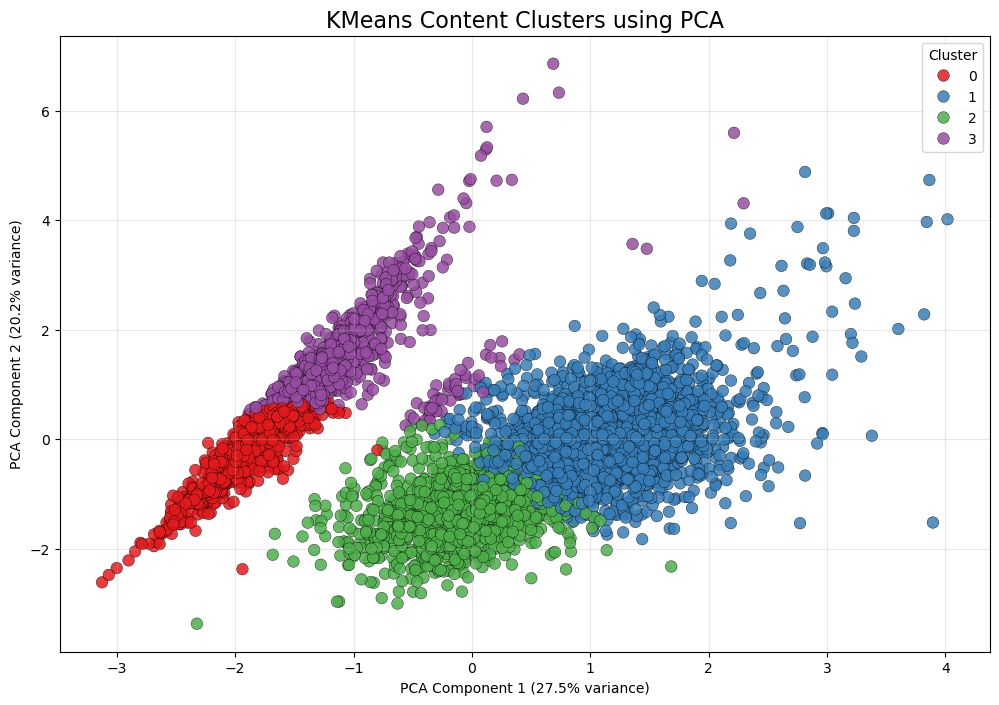


CLUSTER PROFILE

Cluster 0
Total Titles: 1158
Percentage: 15.8%

Average Numeric Values:
release_year: 2016.79
duration: 1.60
cast_count: 3.30
description_word_count: 22.04
content_age: 9.21

Most Common Categories:
Type: TV Show
Genre: International TV Shows
Country: United States

Top 3 Genres:
main_genre
International TV Shows    288
Docuseries                182
Kids' TV                  170
Name: count, dtype: int64

Cluster 1
Total Titles: 3488
Percentage: 47.6%

Average Numeric Values:
release_year: 2014.53
duration: 106.85
cast_count: 9.05
description_word_count: 24.64
content_age: 11.47

Most Common Categories:
Type: Movie
Genre: Dramas
Country: United States

Top 3 Genres:
main_genre
Dramas                1193
Comedies               931
Action & Adventure     570
Name: count, dtype: int64

Cluster 2
Total Titles: 1430
Percentage: 19.5%

Average Numeric Values:
release_year: 2016.63
duration: 79.31
cast_count: 1.89
description_word_count: 22.31
content_age: 9.37

Most Common 

In [63]:
# ========================= KMEANS + PCA + CLUSTER PROFILE =========================

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter data
df_filtered = df[df['release_year'] > 1999].copy().reset_index(drop=True)

# 2. Transform using existing preprocessor
X_filtered = preprocessor.transform(df_filtered[
    [
        'type',
        'release_year',
        'duration',
        'main_genre',
        'main_country',
        'cast_count',
        'description_word_count',
        'content_age'
    ]
])

print(f"Clustering on {X_filtered.shape[0]} titles with {X_filtered.shape[1]} features")

# 3. Train KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_filtered["Cluster"] = kmeans.fit_predict(X_filtered)

print("\nCluster Distribution:")
print(df_filtered["Cluster"].value_counts().sort_index())

# 4. PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_filtered)

# 5. Plot clusters
plt.figure(figsize=(12, 8))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df_filtered["Cluster"],
    palette="Set1",
    s=70,
    alpha=0.85,
    edgecolor="k",
    linewidth=0.3
)

plt.title("KMeans Content Clusters using PCA", fontsize=16)
plt.xlabel(f"PCA Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PCA Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(title="Cluster")
plt.grid(True, alpha=0.3)
plt.show()

# 6. Cluster Profile
print("\n" + "=" * 60)
print("CLUSTER PROFILE")
print("=" * 60)

numeric_cols = [
    'release_year',
    'duration',
    'cast_count',
    'description_word_count',
    'content_age'
]

for cluster_no in sorted(df_filtered["Cluster"].unique()):
    subset = df_filtered[df_filtered["Cluster"] == cluster_no]

    print(f"\nCluster {cluster_no}")
    print(f"Total Titles: {len(subset)}")
    print(f"Percentage: {len(subset) / len(df_filtered) * 100:.1f}%")

    print("\nAverage Numeric Values:")
    for col in numeric_cols:
        print(f"{col}: {subset[col].mean():.2f}")

    print("\nMost Common Categories:")
    print(f"Type: {subset['type'].mode()[0]}")
    print(f"Genre: {subset['main_genre'].mode()[0]}")
    print(f"Country: {subset['main_country'].mode()[0]}")

    print("\nTop 3 Genres:")
    print(subset["main_genre"].value_counts().head(3))

In [64]:
# ================= PCA INTERPRETATION =================

# get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# create dataframe of PCA components
pca_df = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=['PCA1', 'PCA2']
)

# show top contributing features
print("Top features for PCA1:")
print(pca_df.loc['PCA1'].sort_values(ascending=False).head(10))

print("\nTop features for PCA2:")
print(pca_df.loc['PCA2'].sort_values(ascending=False).head(10))

Top features for PCA1:
num__duration                               0.740604
cat__type_Movie                             0.319883
num__description_word_count                 0.295240
num__cast_count                             0.265663
num__content_age                            0.132535
cat__main_genre_Dramas                      0.122980
cat__main_genre_Comedies                    0.092937
cat__main_country_India                     0.082271
cat__main_genre_Action & Adventure          0.062199
cat__main_genre_Children & Family Movies    0.024412
Name: PCA1, dtype: float64

Top features for PCA2:
num__cast_count                             0.721627
num__description_word_count                 0.539396
cat__type_TV Show                           0.179778
cat__main_genre_International TV Shows      0.069086
cat__main_genre_Crime TV Shows              0.036964
cat__main_country_Japan                     0.031266
cat__main_genre_Anime Series                0.026606
cat__main_genre_Kids' TV 

# ========================= CONCLUSION & BUSINESS INSIGHTS =========================

##  Project Summary

In this project, we analyzed Netflix content data using data cleaning, feature engineering, exploratory data analysis, and unsupervised learning techniques (KMeans clustering with PCA visualization).

The objective was to understand patterns in content and group similar titles into meaningful clusters for business interpretation.

---

##  Key Insights from Data

- The dataset contains a mix of Movies and TV Shows, with Movies forming the majority.
- The United States dominates content production, followed by international content.
- Popular genres include **Dramas, Comedies, Documentaries, and International TV Shows**.
- Most content has been added after 2010, showing recent platform growth.
- Cast size, duration, and description length play an important role in defining content characteristics.

---

##  Clustering Results (KMeans)

Using KMeans, the dataset was segmented into **4 distinct clusters**, each representing a different type of content:

### 🔴 Cluster 0 – Casual TV Content
- Short duration, moderate cast
- Genres: Kids TV, Docuseries, International TV Shows  
👉 Represents easy-to-watch, binge-friendly content

---

### 🔵 Cluster 1 – Mainstream Popular Movies
- Long duration, large cast size
- Genres: Drama, Comedy, Action  
👉 Represents high-demand, widely consumed movies

---

### 🟢 Cluster 2 – Niche / Low-Cost Content
- Shorter duration, very small cast
- Genres: Documentaries, Stand-up Comedy  
👉 Represents low-budget, specialized audience content

---

### 🟣 Cluster 3 – Premium TV Shows
- High cast size, multi-episode format
- Genres: Crime TV, International Shows  
👉 Represents high-production, engagement-driven series

---

## Business Insights

### 1. Content Strategy Optimization
- Netflix content is not just "Movies vs TV Shows" — it naturally divides into **4 strategic content categories**
- This allows better planning of content production and acquisition

---

### 2. Recommendation System Improvement
- Clusters can be used to recommend:
  - Casual content → for quick watching
  - Premium shows → for long engagement
  - Niche content → for specific audience interests

---

### 3. Investment Decisions
- High-cast, long-duration content (Cluster 1 & 3) → **high investment, high return**
- Low-cast niche content (Cluster 2) → **low cost, targeted value**

---

### 4. User Engagement Strategy
- TV-based clusters (0 & 3) help increase **watch time and retention**
- Movie clusters (1 & 2) help in **user acquisition and variety**

---

### 5. Market Expansion
- Strong presence of international genres suggests opportunity for **regional content expansion**
- Clustering helps identify underserved niches

---

##  Final Conclusion

This analysis demonstrates how unsupervised learning can uncover hidden patterns in content data. By grouping similar titles, we gain valuable insights into content types, user preferences, and business strategies.

KMeans clustering combined with PCA visualization provides a powerful way to transform raw data into actionable business intelligence.


---